### Overview
This project focuses on predicting property prices in various districts of California using several district-level features. By building a predictive model, we aim to identify key variables that influence housing prices and improve the accuracy of house value predictions. The project will specifically utilize simple linear regression and multiple linear regression to address this regression task, ensuring proper data handling and evaluation of the models.


### Problem Statement
The objective is to predict the median house value in California districts based on features such as income, the number of rooms, geographical location, and proximity to the ocean. Given the dataset, we will develop regression models, evaluate their performance, and determine which model provides the best balance between predictive accuracy and interpretability.

Refer to the **Data information.pdf** for more details on variables before importing the data to the notebook.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Data_file - data_file.csv")
df.head() #display 1st few rows of data 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [3]:
#shows uniques values
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [4]:
df = pd.get_dummies(df, columns=['ocean_proximity'])

In [5]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [6]:
#display basic information about the dataset
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  int64  
 3   total_rooms                 20640 non-null  int64  
 4   total_bedrooms              20433 non-null  float64
 5   population                  20640 non-null  int64  
 6   households                  20640 non-null  int64  
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  int64  
 9   ocean_proximity_<1H OCEAN   20640 non-null  bool   
 10  ocean_proximity_INLAND      20640 non-null  bool   
 11  ocean_proximity_ISLAND      20640 non-null  bool   
 12  ocean_proximity_NEAR BAY    20640 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  206

In [7]:
#summary statistics of dataset
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
# handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Simple linear model - data processing

In [9]:
df_simple = df[['median_income', 'median_house_value']]

In [10]:
df_simple .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_income       20640 non-null  float64
 1   median_house_value  20640 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 322.6 KB


In [11]:
df_simple.describe()

,median_income,median_house_value
count,20640.000000,20640.000000
mean,3.870671,206855.816909
std,1.899822,115395.615874
min,0.499900,14999.000000
25%,2.563400,119600.000000
50%,3.534800,179700.000000
75%,4.743250,264725.000000
max,15.000100,500001.000000


In [12]:
df_simple.head()

,median_income,median_house_value
0,8.3252,452600
1,8.3014,358500
2,7.2574,352100
3,5.6431,341300
4,3.8462,342200


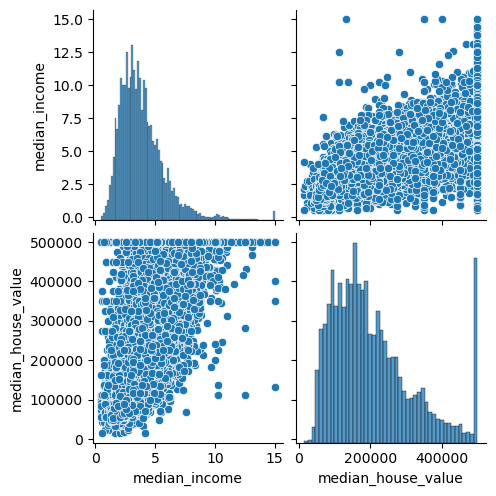

In [13]:
#pairplot to visualize relationships between variables
sns.pairplot(df_simple)
plt.show()

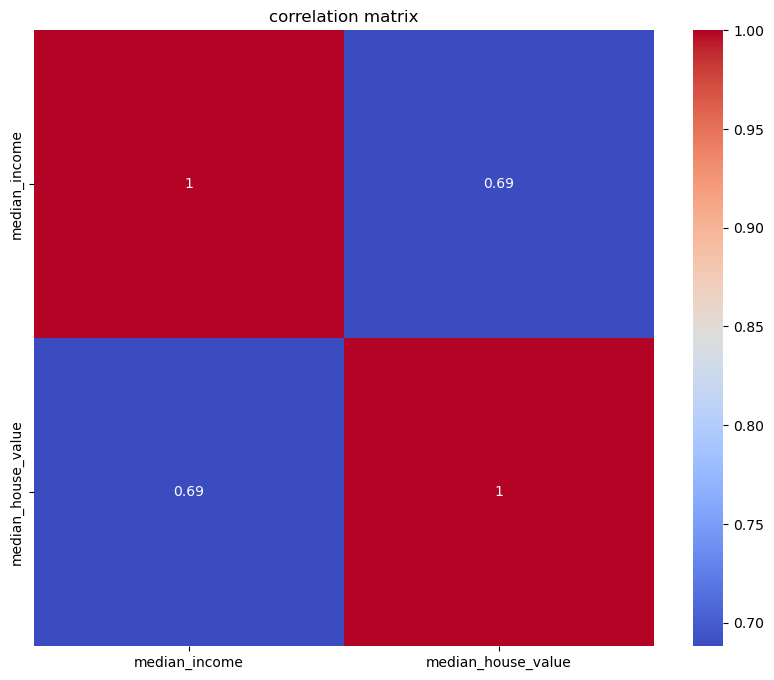

In [14]:
#correlation matrix
correlation_matrix=df_simple.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [15]:
#sns.boxplot(x='median_income',y='median_house_value', data=df_simple)

In [16]:
#sns.jointplot(x='median_income', y='median_house_value', data=df_simple, kind='blue',color='red')

### Training the model

In [17]:
#define the target and predicator varible
X=df_simple[['median_income']]
y=df_simple['median_house_value']

In [18]:
#split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
#create and train the model
simple_model=LinearRegression()
simple_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
#predictions
y_pred=simple_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error: 7091157771.76555
R2 Score: 0.45885918903846656


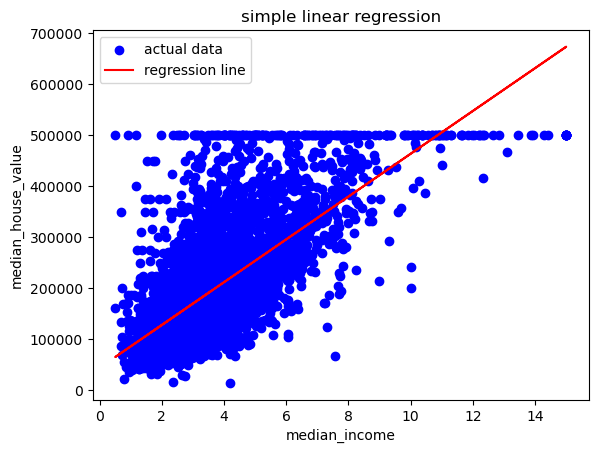

In [21]:
#plot the regression line
plt.scatter(X_test,y_test,color='blue',label='actual data')
plt.plot(X_test,y_pred,color='red',label='regression line')
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.title('simple linear regression')
plt.legend()

### Predicting the median house value using simple regression model

In [22]:
#assuming the model has already been trained and the revelant libraries have veen imported 

#input MedInc value from the user
median_income_value=float(input("enter your medium income value:"))

#convert the input to a 2D array fro the model
median_income_value_array=np.array([[median_income_value]])

#predict the house price using the trained model
predicted_median_house_value = simple_model.predict(median_income_value_array)

#output of  the preduction
median_house_value = predicted_median_house_value [0]

print("The predicted house price for MedInc value of", median_income_value, "is:", median_house_value)

enter your medium income value: 3.8


The predicted house price for MedInc value of 3.8 is: 203808.3568655671


# Multiple linear model - data processing

In [23]:
df_multi=df
df_multi.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,False,True,False


In [24]:
X_multi = df_multi.drop('median_house_value', axis=1)
y_multi = df_multi['median_house_value']

In [25]:
# Split the dataset into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [26]:
#create and train the model
multi_model=LinearRegression()
multi_model.fit(X_train_multi,y_train_multi)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# evalutating the model

In [27]:
#prediction

y_pred_multi = multi_model.predict(X_test_multi)

In [28]:
#display the coefficent of the model
coefficients = pd.DataFrame(multi_model.coef_,X_multi.columns,columns=['Coefficient'])
print(coefficients)

                              Coefficient
longitude                   -26838.273372
latitude                    -25468.352050
housing_median_age            1102.185084
total_rooms                     -6.021506
total_bedrooms                 102.789395
population                     -38.172906
households                      48.252753
median_income                39473.975175
ocean_proximity_<1H OCEAN   -18926.582862
ocean_proximity_INLAND      -58713.239023
ocean_proximity_ISLAND      117198.489753
ocean_proximity_NEAR BAY    -24063.225079
ocean_proximity_NEAR OCEAN  -15495.442789


In [29]:
#evaluate the model
mse = mean_squared_error(y_test_multi, y_pred_multi)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test_multi, y_pred_multi)
print("R2 Score:", r2)

Mean Squared Error: 4904399775.949286
R2 Score: 0.6257351821159696
